
































# Data Acquisition

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.api as sm
from scipy.stats import shapiro, probplot
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

In [ ]:
!pip -q install kagglehub
import kagglehub, os

path = kagglehub.dataset_download(
    "faresashraf1001/supermarket-sales"
)
print("Folder dataset:", path)
print("Daftar file:", os.listdir(path))

100%|██████████| 36.5k/36.5k [00:00<00:00, 41.0MB/s]

Extracting files...
Folder dataset: /root/.cache/kagglehub/datasets/faresashraf1001/supermarket-sales/versions/2
Daftar file: ['SuperMarket Analysis.csv']


In [ ]:
df = pd.read_csv(f'{path}/SuperMarket Analysis.csv')

# Data Understanding

In [ ]:
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


In [ ]:
df.shape

(1000, 17)

In [ ]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [ ]:
df.dtypes

,0
Invoice ID,object
Branch,object
City,object
Customer type,object
Gender,object
Product line,object
Unit price,float64
Quantity,int64
Tax 5%,float64
Sales,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [ ]:
cols = ['Branch', 'City', 'Customer type', 'Gender','Product line', 'Payment']

for c in cols:
    print(f"Unique values in {c}:")
    print(df[c].unique())
    print("-" * 40)

Unique values in Branch:
['Alex' 'Giza' 'Cairo']
----------------------------------------
Unique values in City:
['Yangon' 'Naypyitaw' 'Mandalay']
----------------------------------------
Unique values in Customer type:
['Member' 'Normal']
----------------------------------------
Unique values in Gender:
['Female' 'Male']
----------------------------------------
Unique values in Product line:
['Health and beauty' 'Electronic accessories' 'Home and lifestyle'
 'Sports and travel' 'Food and beverages' 'Fashion accessories']
----------------------------------------
Unique values in Payment:
['Ewallet' 'Cash' 'Credit card']
----------------------------------------


In [ ]:
#Persentase Margin Kotor Ditetapkan pada 4,7619% sehingga perlu di hapus sebab tidak ada variasi nilai antar observasi
df = df.drop(columns=['gross margin percentage'])

In [ ]:
# Menampilkan hanya kolom dengan tipe data numerik
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_cols)

['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'cogs', 'gross income', 'Rating']


In [ ]:
# Menampilkan hanya kolom dengan tipe data object (nominal)
obj_cols = df.select_dtypes(include='object').columns.tolist()
print(obj_cols)

['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Date', 'Time', 'Payment']


In [ ]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,49.650000,10.00000


In [ ]:
df.isna().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


# Data Preparation

###Missing Value

In [ ]:
print(df.isnull().sum().sum())

0


###Data Duplikat

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,False
997,False
998,False


###Handling Outlier

In [ ]:
# Pilih kolom numerik
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
# Deteksi outlier menggunakan metode IQR
def detect_outliers_iqr(df, columns):
    outlier_summary = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Hitung jumlah outlier
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary[col] = len(outliers)

        print(f" Kolom: {col}")
        print(f"   Jumlah outlier: {len(outliers)}")
        print(f"   Batas bawah: {lower_bound:.2f}, Batas atas: {upper_bound:.2f}\n")

    return outlier_summary
# Jalankan fungsi
outlier_counts = detect_outliers_iqr(df, numeric_cols)

 Kolom: Unit price
   Jumlah outlier: 0
   Batas bawah: -34.72, Batas atas: 145.53

 Kolom: Quantity
   Jumlah outlier: 0
   Batas bawah: -4.50, Batas atas: 15.50

 Kolom: Tax 5%
   Jumlah outlier: 9
   Batas bawah: -18.86, Batas atas: 47.23

 Kolom: Sales
   Jumlah outlier: 9
   Batas bawah: -395.97, Batas atas: 991.74

 Kolom: cogs
   Jumlah outlier: 9
   Batas bawah: -377.11, Batas atas: 944.52

 Kolom: gross income
   Jumlah outlier: 9
   Batas bawah: -18.86, Batas atas: 47.23

 Kolom: Rating
   Jumlah outlier: 0
   Batas bawah: 1.00, Batas atas: 13.00



##### Berdasarkan hasil identifikasi outlier di atas, dapat disimpulkan bahwa mayoritas variabel memiliki sebaran data yang normal tanpa adanya nilai yang menyimpang jauh, kecuali pada beberapa variabel finansial. Kolom **Tax 5%**, **Sales**, **cogs**, dan **gross income** masing-masing terdeteksi memiliki **9 outlier**, yang menunjukkan adanya transaksi dengan nilai pajak, penjualan, dan keuntungan yang jauh lebih besar dibandingkan data lainnya. Kondisi ini dapat dianggap wajar karena keempat variabel tersebut saling berhubungan langsung dengan total nilai transaksi, sehingga variasi besar pada nominal tertentu dapat menghasilkan nilai ekstrem. Sementara itu, variabel **Unit price**, **Quantity**, dan **Rating** tidak menunjukkan adanya outlier, menandakan bahwa harga produk, jumlah pembelian, serta penilaian pelanggan relatif stabil dan berada dalam kisaran yang normal di seluruh dataset.

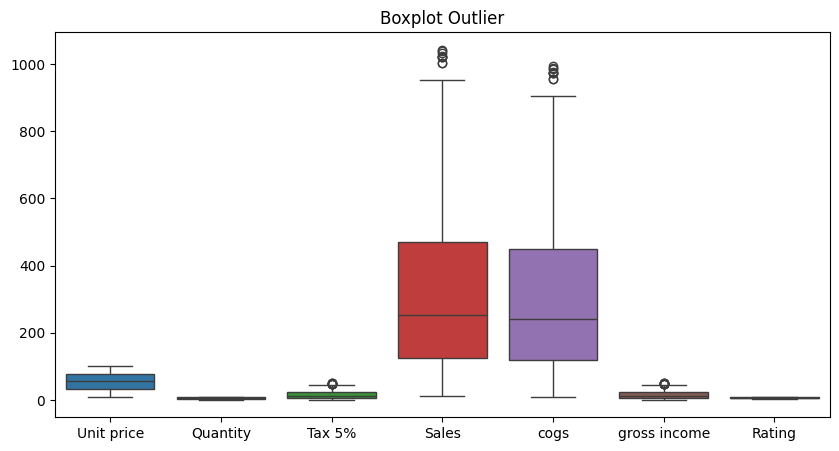

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[num_cols])
plt.title('Boxplot Outlier')
plt.show()

Berdasarkan hasil boxplot, terlihat bahwa variabel **Tax 5%**, **Sales**, **COGS**, dan **gross income** memiliki sejumlah **outlier**, masing-masing sebanyak 9 data. Sementara itu, variabel **Unit price**, **Quantity**, dan **Rating** tidak memiliki outlier. Hal ini menunjukkan bahwa sebagian besar data berada dalam rentang normal, namun terdapat beberapa nilai ekstrem pada variabel keuangan yang kemungkinan berasal dari transaksi dengan nilai penjualan yang sangat tinggi.


In [ ]:
#Handling Outlier dengan metode Winsorization (Capping IQR)
outlier_limits = {
    'Tax 5%': (-18.86, 47.23),
    'Sales': (-395.97, 991.74),
    'cogs': (-377.11, 944.52),
    'gross income': (-18.86, 47.23)
}

def winsorize(df, col, lower, upper):
    df[col] = df[col].clip(lower=lower, upper=upper)

for col, (lower, upper) in outlier_limits.items():
    winsorize(df, col, lower, upper)

print("Outlier ditangani menggunakan metode Winsorization (Capping IQR)")

Outlier ditangani menggunakan metode Winsorization (Capping IQR)


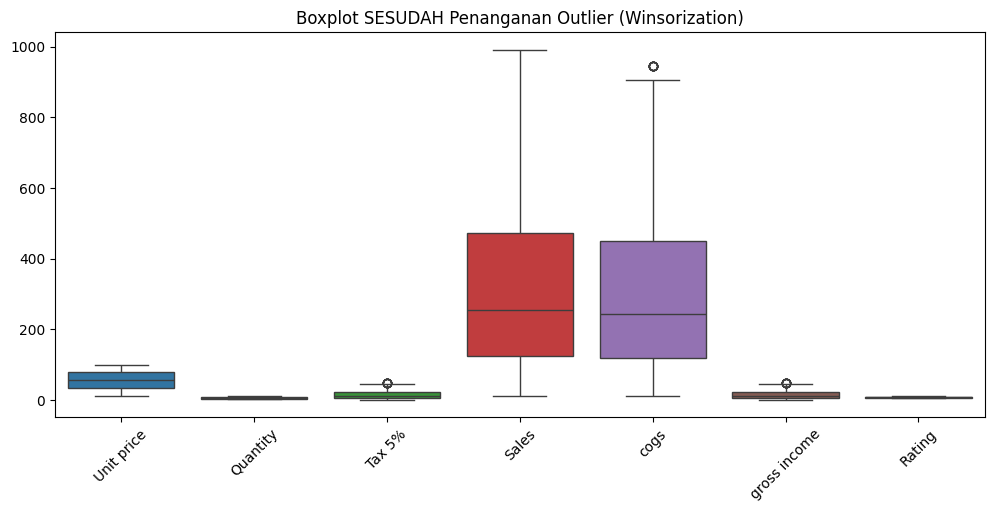

In [ ]:
#Boxplot Sesudah penanganan Outlier
plt.figure(figsize=(12,5))
sns.boxplot(data=df[['Unit price','Quantity','Tax 5%','Sales','cogs','gross income','Rating']])
plt.title("Boxplot SESUDAH Penanganan Outlier (Winsorization)")
plt.xticks(rotation=45)
plt.show()

Boxplot menunjukkan bahwa nilai ekstrem (outlier) telah berhasil dibatasi (capped) pada batas IQR, terutama terlihat pada variabel Sales dan cogs. Kedua variabel ini tetap menjadi yang paling dispersif (memiliki IQR terbesar) meskipun outlier-nya sudah diatasi. Sebaliknya, variabel seperti Quantity dan Rating menunjukkan dispersi yang sangat minimal, menandakan sebagian besar datanya terkonsentrasi di satu nilai rendah

### Bentuk distribusi data

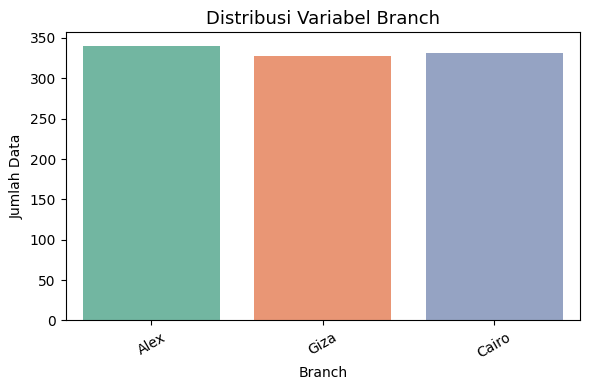

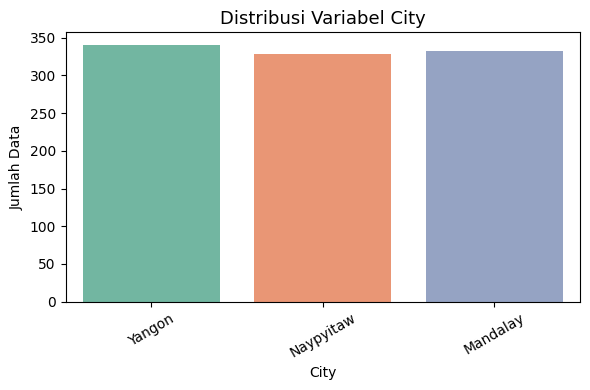

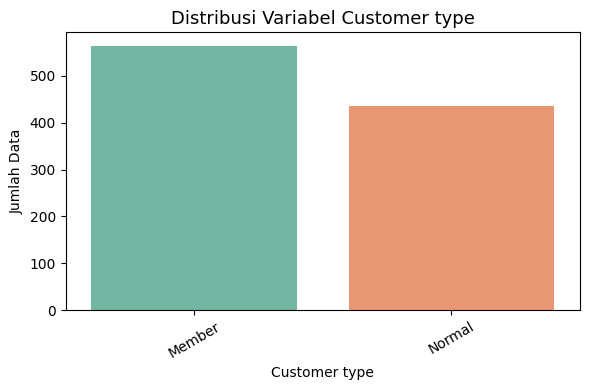

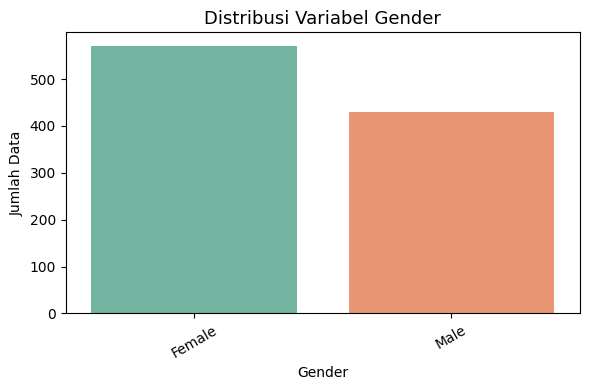

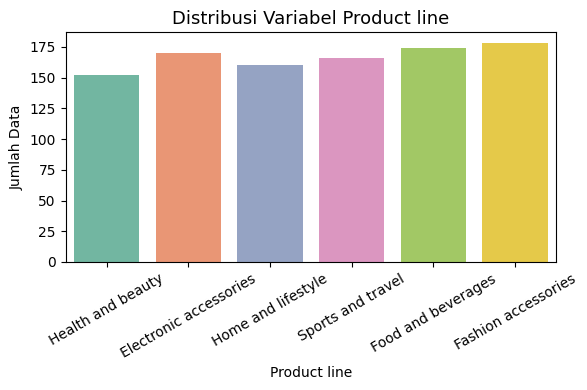

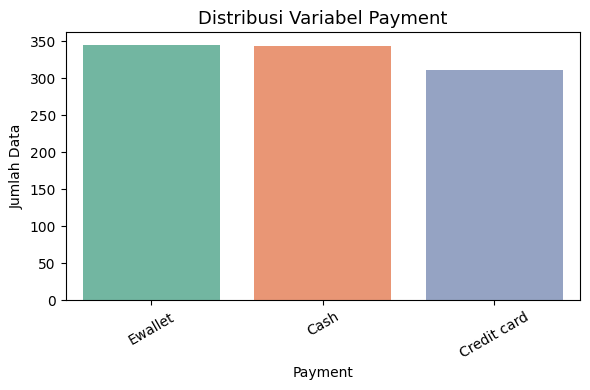

In [ ]:
# Daftar kolom kategorikal
cat_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']

# Loop setiap variabel kategorikal
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue=col, data=df, palette='Set2', legend=False)
    plt.title(f'Distribusi Variabel {col}', fontsize=13)
    plt.xlabel(col)
    plt.ylabel('Jumlah Data')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

Berdasarkan hasil visualisasi, data menunjukkan bahwa distribusi pada variabel *Branch* dan *City* relatif merata di antara ketiga cabang, yaitu Alex, Giza, dan Cairo. Sebagian besar pelanggan merupakan tipe *Member* dibandingkan *Normal*, serta jumlah pelanggan perempuan lebih banyak dibandingkan laki-laki. Distribusi produk pada variabel *Product line* juga terlihat cukup seimbang, dengan kategori *Fashion accessories* dan *Food and beverages* sedikit lebih dominan dibandingkan kategori lainnya. Selain itu, pada variabel *Payment*, metode pembayaran *Ewallet* dan *Cash* digunakan hampir dalam jumlah yang sama, dengan transaksi *Credit Card* sedikit lebih rendah dibanding keduanya.


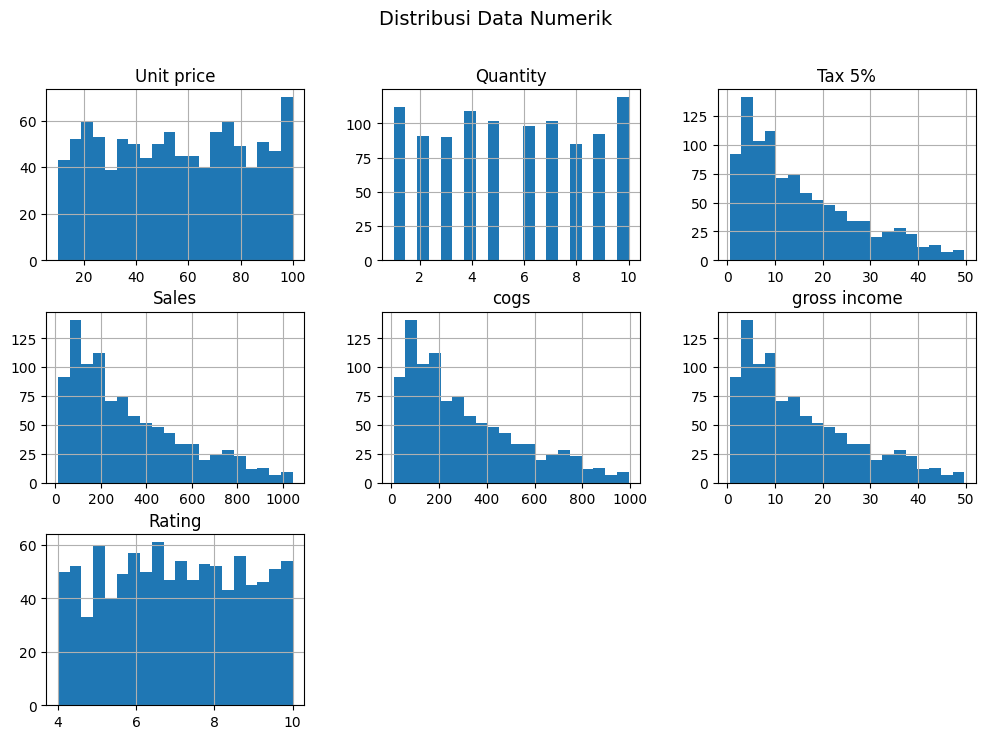

In [ ]:
# Histogram
df[num_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distribusi Data Numerik", fontsize=14)
plt.show()

Berdasarkan visualisasi distribusi data numerik, dapat disimpulkan bahwa sebagian besar variabel keuangan seperti **Sales**, **COGS**, **gross income**, dan **Tax 5%** memiliki distribusi yang **condong ke kanan (right-skewed)**. Hal ini menunjukkan bahwa sebagian besar transaksi memiliki nilai yang relatif kecil, sementara hanya sedikit transaksi dengan nilai yang besar. Sementara itu, variabel **Unit price** dan **Rating** menunjukkan pola distribusi yang relatif **merata (uniform)**, menandakan bahwa nilai-nilai pada variabel tersebut tersebar cukup seimbang di seluruh rentang data. Variabel **Quantity** juga tampak terdistribusi secara merata pada kisaran 1 hingga 10.


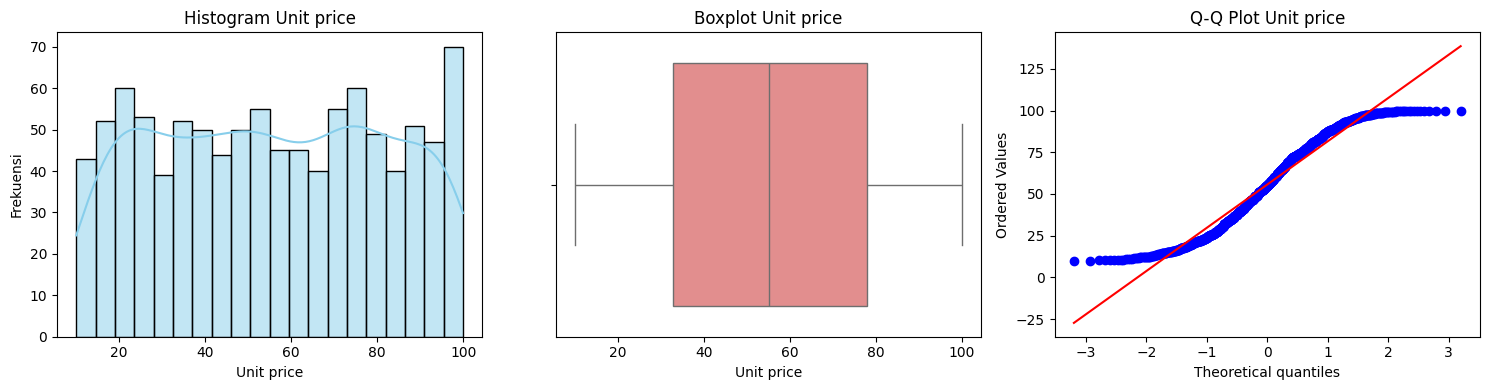

📊 Kolom: Unit price
   ➤ Skewness: 0.0071
   ➤ Shapiro-Wilk: Statistik = 0.9519, p-value = 0.0000 → Tidak Normal
----------------------------------------------------------------------


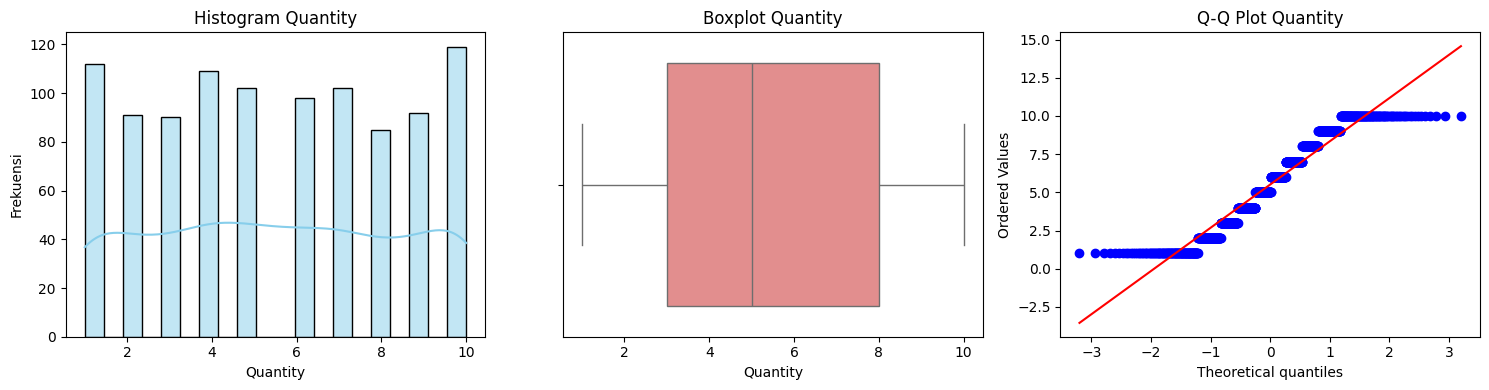

📊 Kolom: Quantity
   ➤ Skewness: 0.0129
   ➤ Shapiro-Wilk: Statistik = 0.9326, p-value = 0.0000 → Tidak Normal
----------------------------------------------------------------------


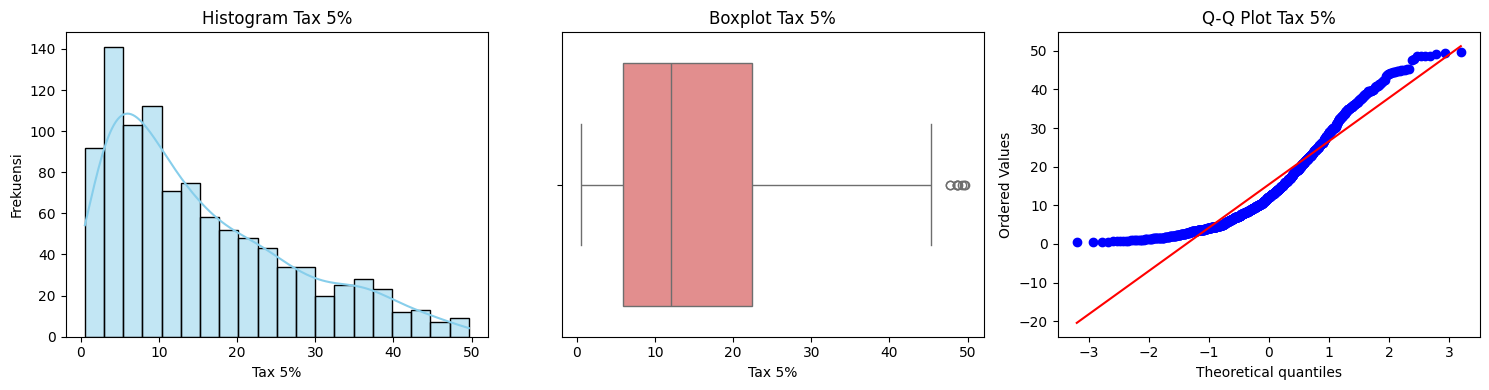

📊 Kolom: Tax 5%
   ➤ Skewness: 0.8926
   ➤ Shapiro-Wilk: Statistik = 0.9088, p-value = 0.0000 → Tidak Normal
----------------------------------------------------------------------


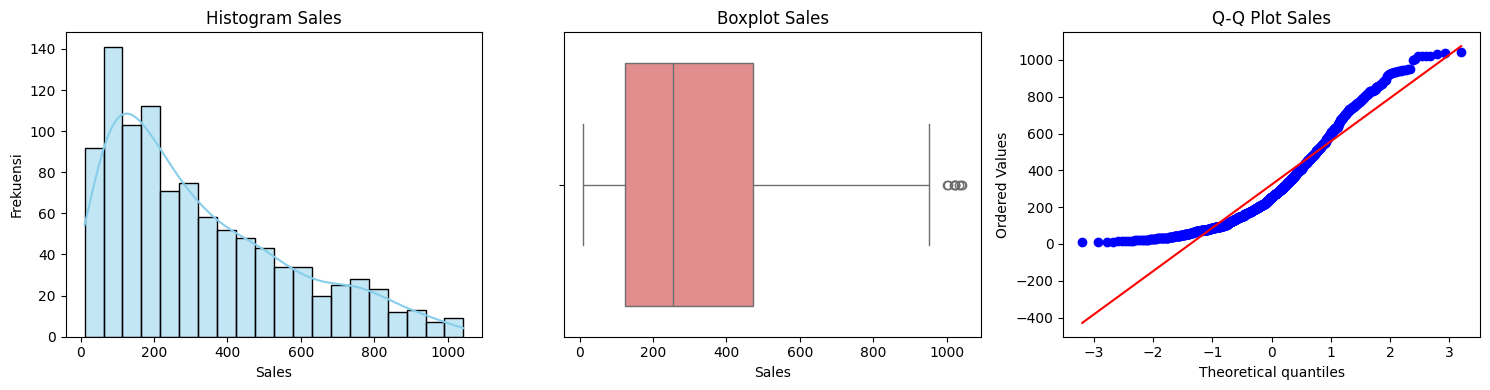

📊 Kolom: Sales
   ➤ Skewness: 0.8926
   ➤ Shapiro-Wilk: Statistik = 0.9088, p-value = 0.0000 → Tidak Normal
----------------------------------------------------------------------


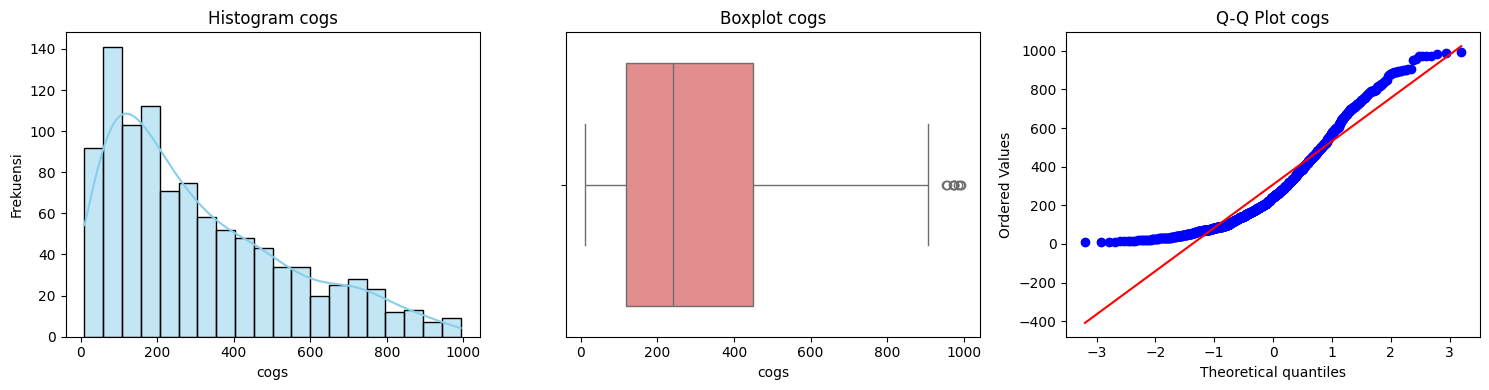

📊 Kolom: cogs
   ➤ Skewness: 0.8926
   ➤ Shapiro-Wilk: Statistik = 0.9088, p-value = 0.0000 → Tidak Normal
----------------------------------------------------------------------


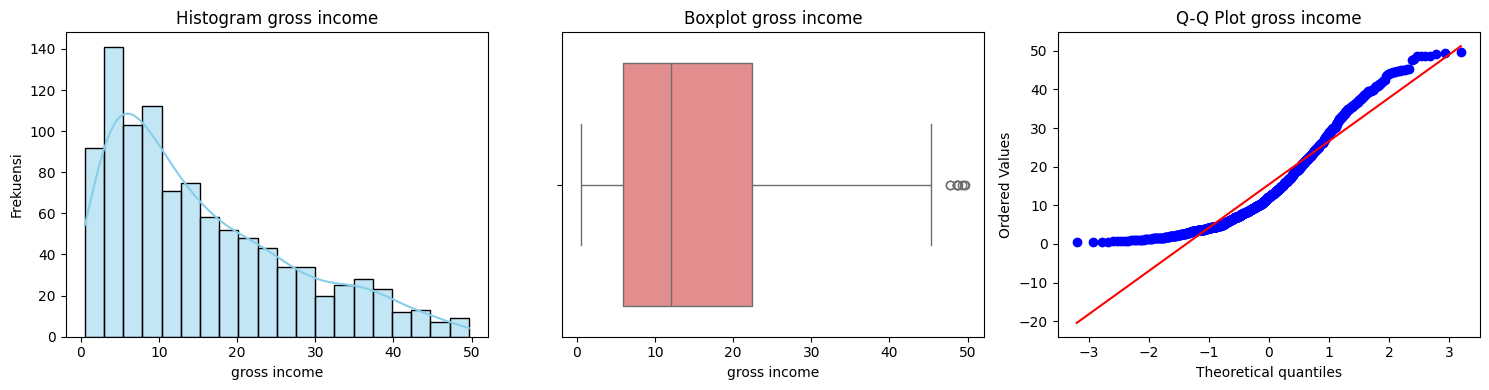

📊 Kolom: gross income
   ➤ Skewness: 0.8926
   ➤ Shapiro-Wilk: Statistik = 0.9088, p-value = 0.0000 → Tidak Normal
----------------------------------------------------------------------


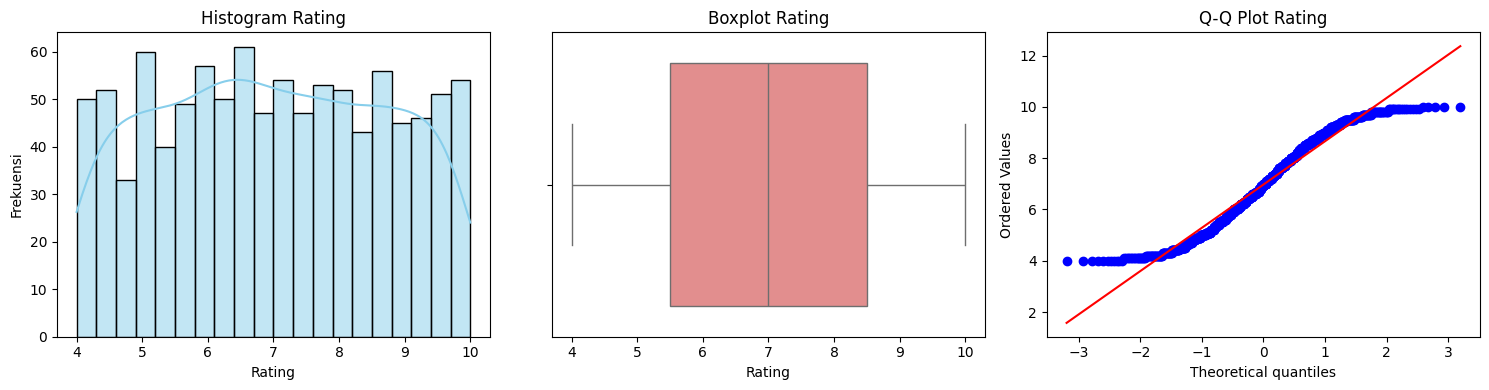

📊 Kolom: Rating
   ➤ Skewness: 0.0090
   ➤ Shapiro-Wilk: Statistik = 0.9582, p-value = 0.0000 → Tidak Normal
----------------------------------------------------------------------


In [ ]:
# Loop untuk setiap kolom numerik
for col in num_cols:
    plt.figure(figsize=(15, 4))

    # ===== 1. Histogram =====
    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Histogram {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

    # ===== 2. Boxplot =====
    plt.subplot(1, 3, 2)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot {col}')
    plt.xlabel(col)

    # ===== 3. Q-Q Plot =====
    plt.subplot(1, 3, 3)
    probplot(df[col].dropna(), dist='norm', plot=plt)
    plt.title(f'Q-Q Plot {col}')

    plt.tight_layout()
    plt.show()

    # ===== Statistik Deskriptif =====
    skew_val = df[col].skew()
    stat, p = shapiro(df[col].dropna())
    normal = "Normal" if p > 0.05 else "Tidak Normal"

    print(f"📊 Kolom: {col}")
    print(f"   ➤ Skewness: {skew_val:.4f}")
    print(f"   ➤ Shapiro-Wilk: Statistik = {stat:.4f}, p-value = {p:.4f} → {normal}")
    print("-" * 70)

**Uji Shapiro-Wilk**

####**Hipotesis**

H₀: Data berdistribusi normal

H₁: Data tidak berdistribusi normal


####**Statistik Uji & P-Value**

p ≤ 0.05: Tolak H₀ artinya data berbeda signifikan dari normal (Data tidak berdistribusi normal)

p > 0.05: Gagal menolak H₀ artinya data tidak berbeda signifikan dari normal (Data berdistribusi normal)

####**Nilai Kemiringan (Skewness)**
: Mengukur derajat asimetris distribusi data.

Skewness = 0 → Simetris (normal)

Skewness > 0 → Miring ke kanan

Skewness < 0 → Miring ke kiri

####**Nilai Statistik (W)**
: Nilai hasil uji Shapiro–Wilk yang menunjukkan kedekatan distribusi data dengan distribusi normal.

W mendekati 1 → Data mendekati normal

W jauh dari 1 → Data menyimpang dari normal


##### > Uji Shapiro-Wilk:
- Nilai p-value untuk semua kolom adalah 0.0000, yang jauh lebih kecil dari tingkat signifikansi alpha(misalnya, 0.05). Oleh karena itu, hipotesis nol (data terdistribusi normal) ditolak untuk semua variabel. Hal ini dikonfirmasi oleh QQ Plot yang menunjukkan penyimpangan signifikan dari garis lurus, dan Histogram yang tidak berbentuk lonceng sempurna.
##### > Skewness:
- Unit price, Quantity, Rating: Nilai Skewness sangat mendekati 0 (0.0071, 0.0129, 0.0090). Secara visual (pada Histogram), kolom-kolom ini cenderung simetris. Meskipun simetris, uji Shapiro-Wilk menunjukkan mereka tidak normal (kemungkinan karena kurtosis atau ukuran sampel besar yang membuat uji ini sangat sensitif).Tax 5%, Sales, cogs, gross income: Nilai Skewness positif (sekitar 0.877). Ini mengindikasikan distribusi condong ke kanan (positively skewed). Secara visual, Histogram untuk kolom-kolom ini menunjukkan ekor yang memanjang ke arah nilai positif/tinggi.

📊 **KESIMPULAN:**

Berdasarkan hasil uji Shapiro–Wilk, seluruh variabel memiliki p-value lebih kecil dari 0,05, sehingga H₀ ditolak. Artinya, semua variabel tidak berdistribusi normal.

Hal ini juga didukung oleh:

- Nilai kemiringan (skewness) yang menunjukkan distribusi tidak simetris, dan

- Nilai statistik Shapiro–Wilk (W) yang jauh dari 1,

serta tampilan Q–Q Plot yang memperlihatkan titik-titik data tidak mengikuti garis diagonal merah.

# **Analisis Korelasi**

### **Variabel Numerik**

In [ ]:
#korelasi dengan metode Spearman: Data tidak berdistribusi normal
num_cols = ['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'cogs', 'gross income', 'Rating']
df_num = df[num_cols]

corr_spearman = df_num.corr(method='spearman')
print("Matriks Korelasi Spearman:")
corr_spearman

Matriks Korelasi Spearman:


,Unit price,Quantity,Tax 5%,Sales,cogs,gross income,Rating
Unit price,1.000000,0.011167,0.630054,0.630054,0.630054,0.630054,-0.008335
Quantity,0.011167,1.000000,0.735265,0.735265,0.735265,0.735265,-0.015453
Tax 5%,0.630054,0.735265,1.000000,1.000000,1.000000,1.000000,-0.017226
Sales,0.630054,0.735265,1.000000,1.000000,1.000000,1.000000,-0.017226
cogs,0.630054,0.735265,1.000000,1.000000,1.000000,1.000000,-0.017226
gross income,0.630054,0.735265,1.000000,1.000000,1.000000,1.000000,-0.017226
Rating,-0.008335,-0.015453,-0.017226,-0.017226,-0.017226,-0.017226,1.000000


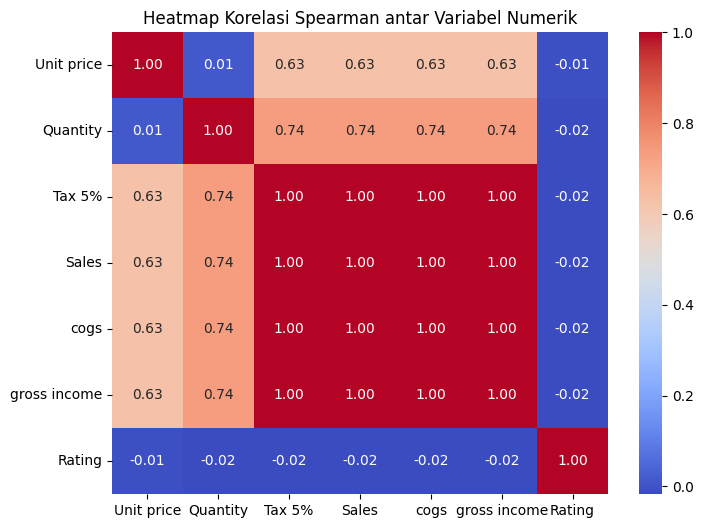

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Spearman antar Variabel Numerik")
plt.show()

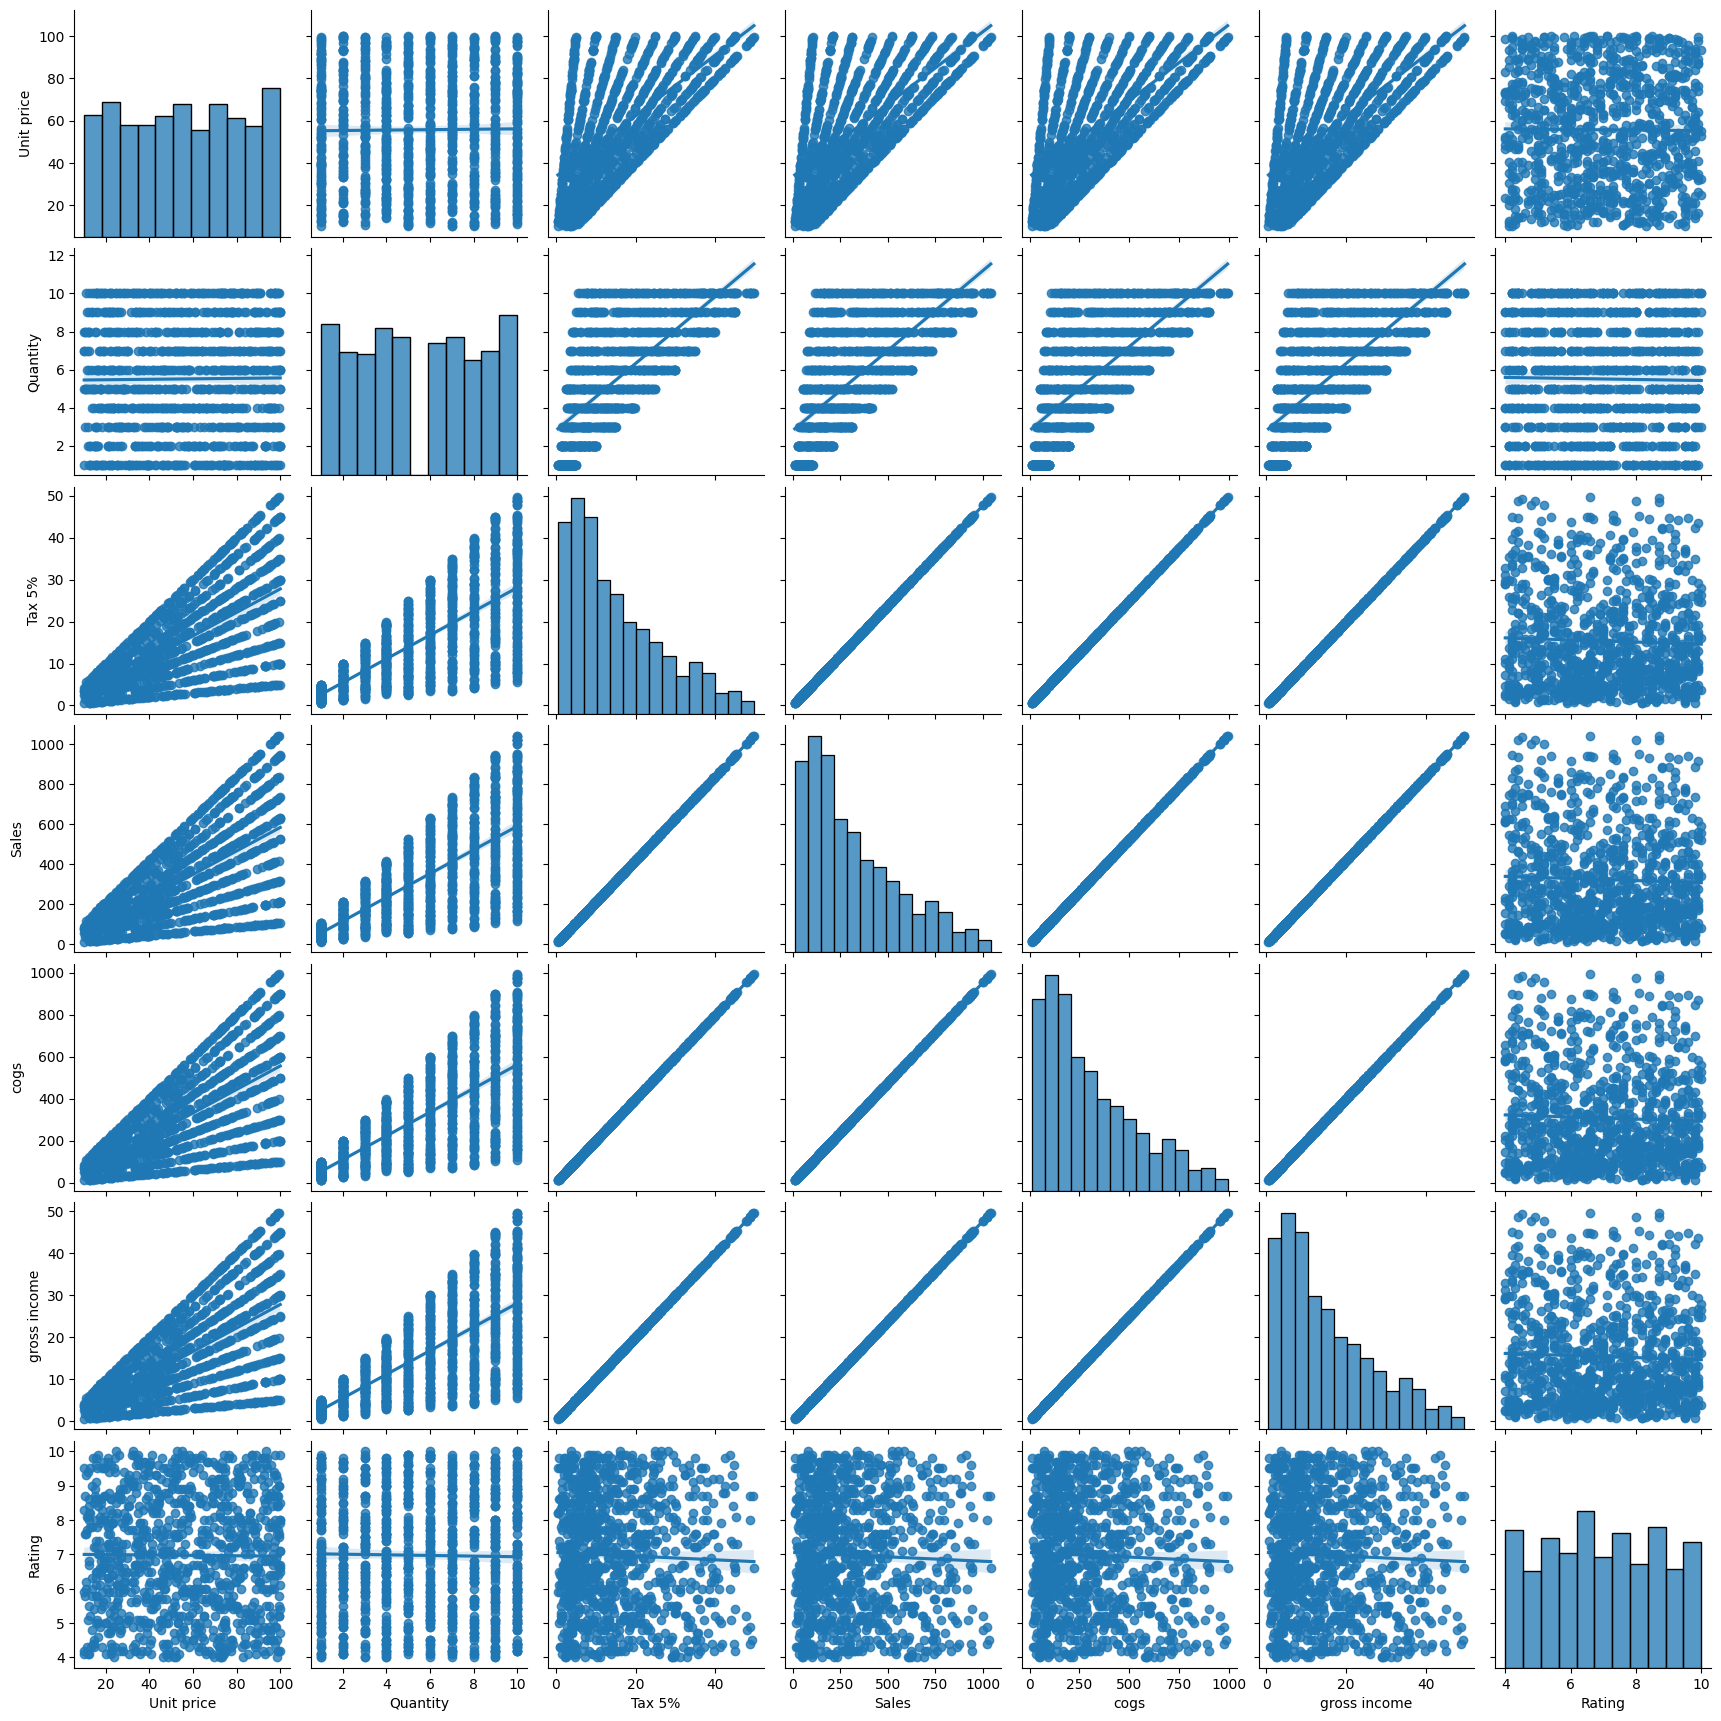

In [ ]:
sns.pairplot(df_num , vars=df_num, kind='reg')
plt.show()

### **Variabel Kategorikal**

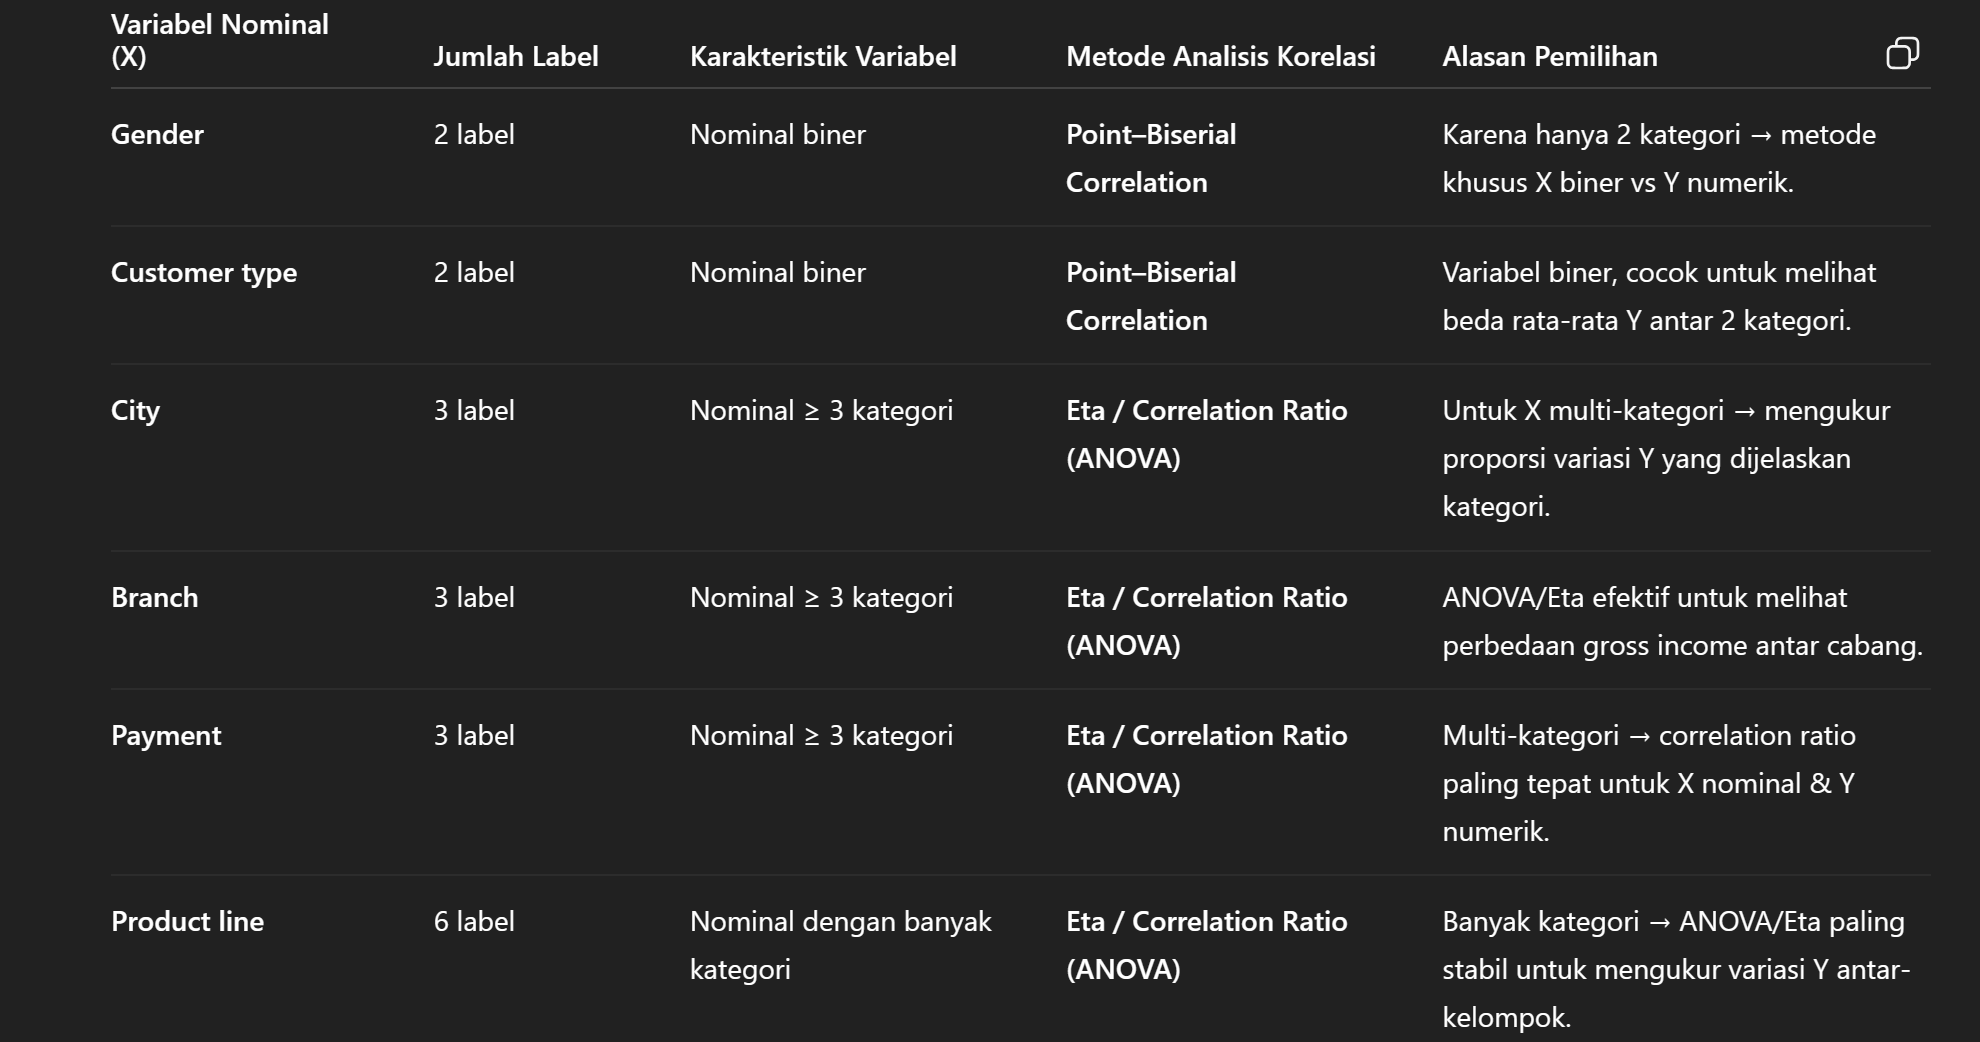

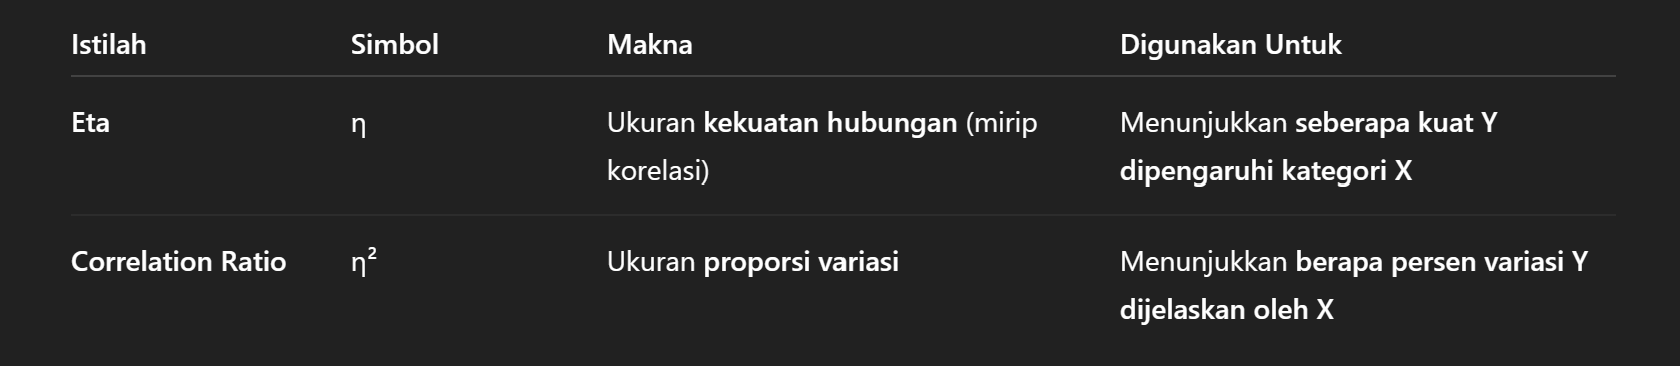

In [ ]:
# 1. FUNCTION POINT BISERIAL
def point_biserial(df, cat_var, target):
    le = LabelEncoder()
    x = le.fit_transform(df[cat_var])
    y = df[target]
    r, p = pointbiserialr(x, y)
    return r, p

# 2. FUNCTION ETA (η) & η²
def eta_correlation(df, cat_var, target):
    y = df[target]
    grand_mean = y.mean()
    ss_between = 0
    for level in df[cat_var].unique():
        group = df[df[cat_var] == level][target]
        ss_between += len(group) * (group.mean() - grand_mean)**2
    ss_total = ((y - grand_mean)**2).sum()
    eta_squared = ss_between / ss_total
    eta = np.sqrt(eta_squared)
    return eta, eta_squared

# 3. DAFTAR VAR LABEL & METODE YANG DIGUNAKAN
binary_vars = ["Gender", "Customer type"]   # 2 kategori → point biserial
multi_vars = ["City", "Branch", "Payment", "Product line"]  # ≥3 kategori → eta
target = "gross income"

# 4. HITUNG POINT BISERIAL + SIMPAN KE DATAFRAME
pb_results = []
for var in binary_vars:
    r, p = point_biserial(df, var, target)
    pb_results.append([var, "Point-Biserial", r, p])
df_point_biserial = pd.DataFrame(pb_results,
                                 columns=["Variable", "Method", "Correlation_r", "p_value"])

# 5. HITUNG ETA + SIMPAN KE DATAFRAME
eta_results = []  # list untuk menampung hasil
for var in multi_vars:
    eta, eta2 = eta_correlation(df, var, target)
    eta_results.append([var, "ETA / Correlation Ratio", eta, eta2])
df_eta = pd.DataFrame(eta_results,
                      columns=["Variable", "Method", "Eta", "Eta_squared"])

# 6. CETAK OUTPUT
print("=== Metode Point Biserial ===")
display(df_point_biserial)
print("=== Metode ETA/Correlation Ratio ===")
display(df_eta)

=== Metode Point Biserial ===


,Variable,Method,Correlation_r,p_value
0,Gender,Point-Biserial,-0.084332,0.007625
1,Customer type,Point-Biserial,-0.059247,0.061089


=== Metode ETA/Correlation Ratio ===


,Variable,Method,Eta,Eta_squared
0,City,ETA / Correlation Ratio,0.042087,0.001771
1,Branch,ETA / Correlation Ratio,0.042087,0.001771
2,Payment,ETA / Correlation Ratio,0.012754,0.000163
3,Product line,ETA / Correlation Ratio,0.041196,0.001697


Asumsi pada Metode Point Biserial
- Hipotesis

H₀: Tidak ada hubungan yang signifikan

H₁: Ada hubungan yang signifikan

- Statistik Uji & P-Value

p ≤ 0.05: Tolak H₀ artinya ada hubungan yang signifikan antara variabel kategorikal dan variabel kontinu.

p > 0.05: Gagal menolak H₀ artinya data tidak ada hubungan yang signifikan antara variabel kategorikal dan variabel kontinu.

#**Analisis Korelasi Variabel Kategorikal terhadap Gross Income**

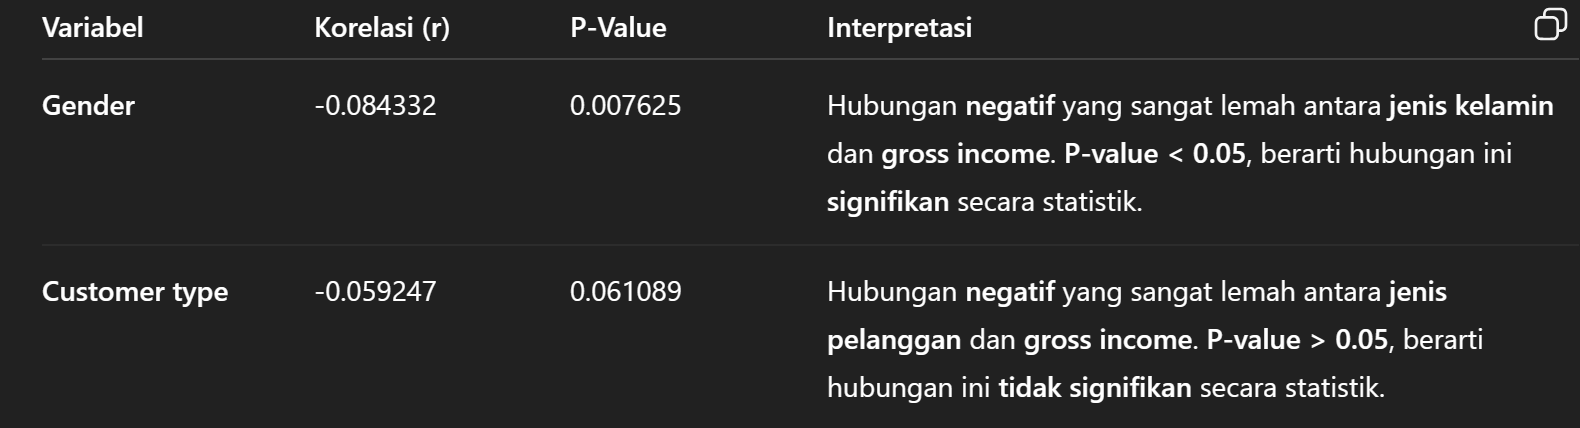

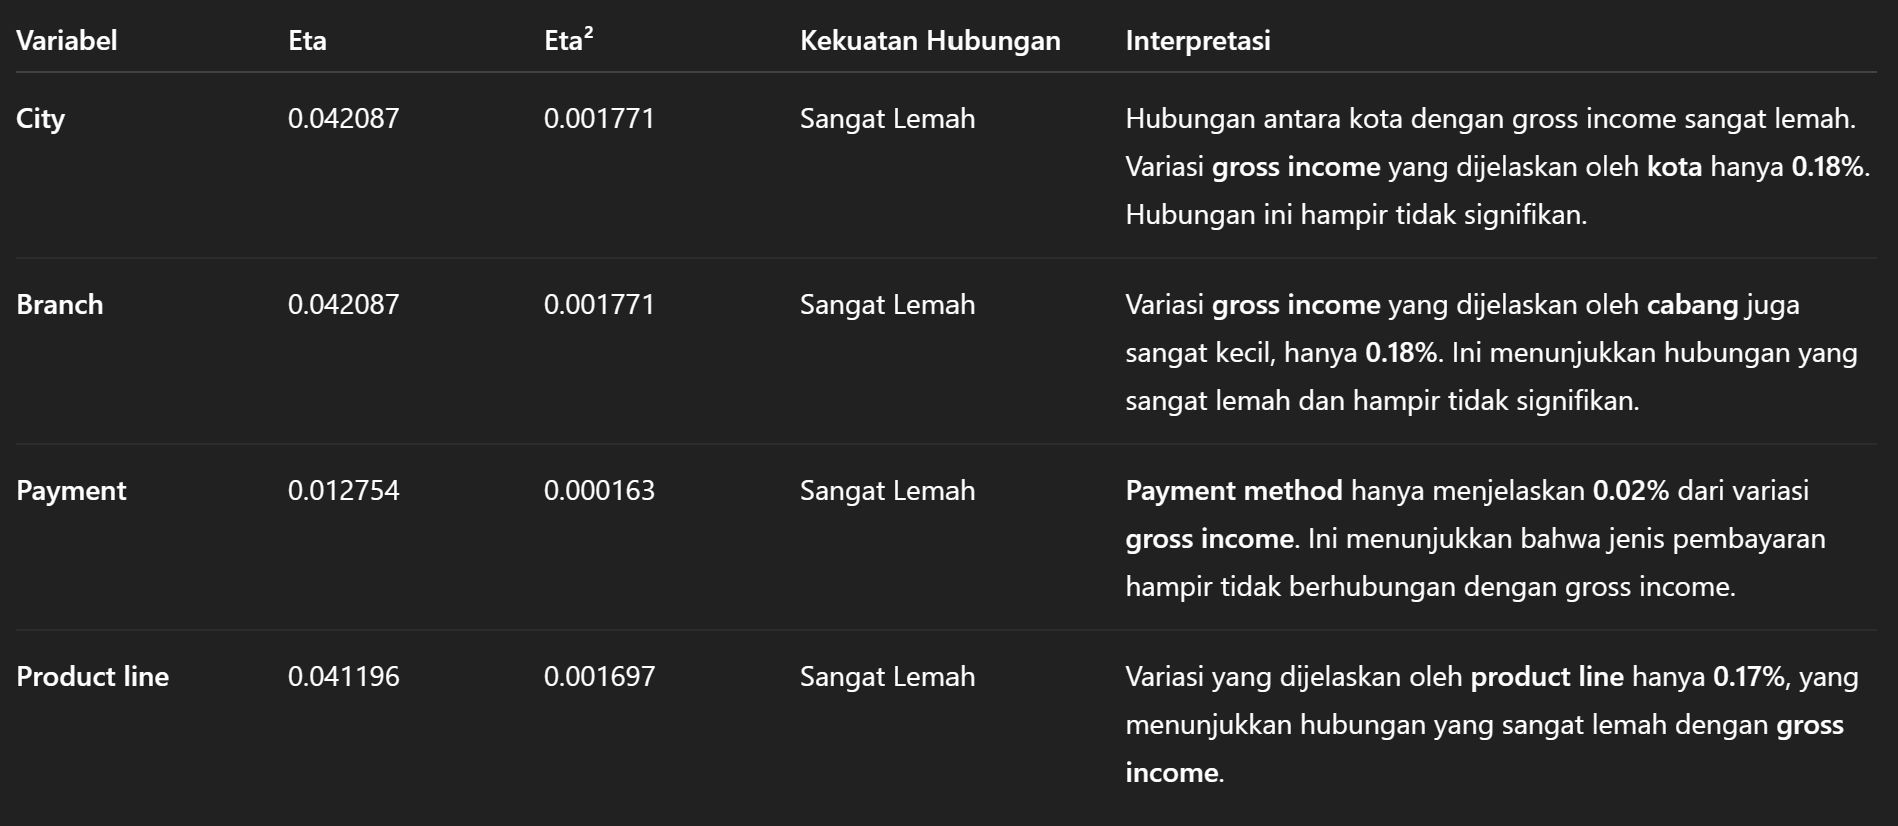

KESIMPULAN
- Gender adalah satu-satunya variabel yang menunjukkan hubungan signifikan dengan gross income, meskipun efeknya lemah.

- Customer type, bersama dengan variabel-variabel lainnya seperti City, Branch, Payment, dan Product line, tidak menunjukkan hubungan yang signifikan dengan gross income, dan variasi yang dijelaskan oleh variabel-variabel ini sangat kecil.